In [47]:
import pandas as pd

In [48]:
df=pd.read_csv("C:\\Users\\deept\\Downloads\\Titanic-Dataset.csv")
df.head

<bound method NDFrame.head of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                     

Exploratory Data Analysis
Data Exploration

In [49]:
df.shape

(891, 12)

In [50]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [52]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Data cleaning

Null values

In [53]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [54]:
df=df.drop("Cabin",axis=1)

In [55]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
dtype: int64

In [56]:
df["Age"].skew()

np.float64(0.38910778230082704)

<50-not skewed
=50-normal
>50-skewed

so replace it by mean

In [57]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [58]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64

1) Embarked is replaced by mode as it is categorical data
2) Mean and median replaces numerical values
3) Mean for normal skewed
4) median for skewed

In [59]:
df["Embarked"]=df["Embarked"].fillna(df["Embarked"].mode()[0])

In [60]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Duplicates

In [61]:
df.duplicated().sum()

np.int64(0)

Outliers

In [62]:
import numpy as np
Data=df.select_dtypes(include=np.number)

In [63]:
for i in Data:
    q1=Data[i].quantile(0.25)
    q2=Data[i].quantile(0.50)
    q3=Data[i].quantile(0.75)

In [64]:
IQR=q3-q1

In [65]:
IQR

np.float64(23.0896)

In [66]:
UW=q3+1.5*IQR
LW=q1-1.5*IQR

In [67]:
Outlier=((Data[i]>UW)&(Data[i]<LW))

In [68]:
Outlier.sum()

np.int64(0)

Data Analysis / Transformation

In [70]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [71]:
print(df["PassengerId"].count())

891


In [87]:
pd.DataFrame(df["Survived"].value_counts())

,count
Survived,
0,549
1,342


Most people died in the incident

In [73]:
df.groupby("Sex")["Survived"].mean()*100

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64

Most of the female survived in the incident

Bining - to create column

In [75]:
bins = [0,18,36,70]
labels={"child","adult","old"}
df["AgeGroup"]=pd.cut(df["Age"],bins=bins,labels=labels)

In [76]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,old
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,old
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,old
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,old


In [77]:
df.groupby("AgeGroup")["Survived"].mean()*100

C:\Users\deept\AppData\Local\Temp\ipykernel_3168\1430959362.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()*100


AgeGroup
child    50.359712
old      35.906643
adult    37.368421
Name: Survived, dtype: float64

More children were saved in the incident

In [81]:
df.groupby("Pclass")["Survived"].mean()*100

Pclass
1    62.962963
2    47.282609
3    24.236253
Name: Survived, dtype: float64

most of the first class people were survived.

In [82]:
df["FamilyMember"]=df["SibSp"]+df["Parch"]

In [83]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,AgeGroup,FamilyMember
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,old,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,adult,1
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,old,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,old,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,old,0


In [86]:
df["FamilyMember"].mean()*100

np.float64(90.46015712682379)

90% of the passengers had family members

data visualization

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

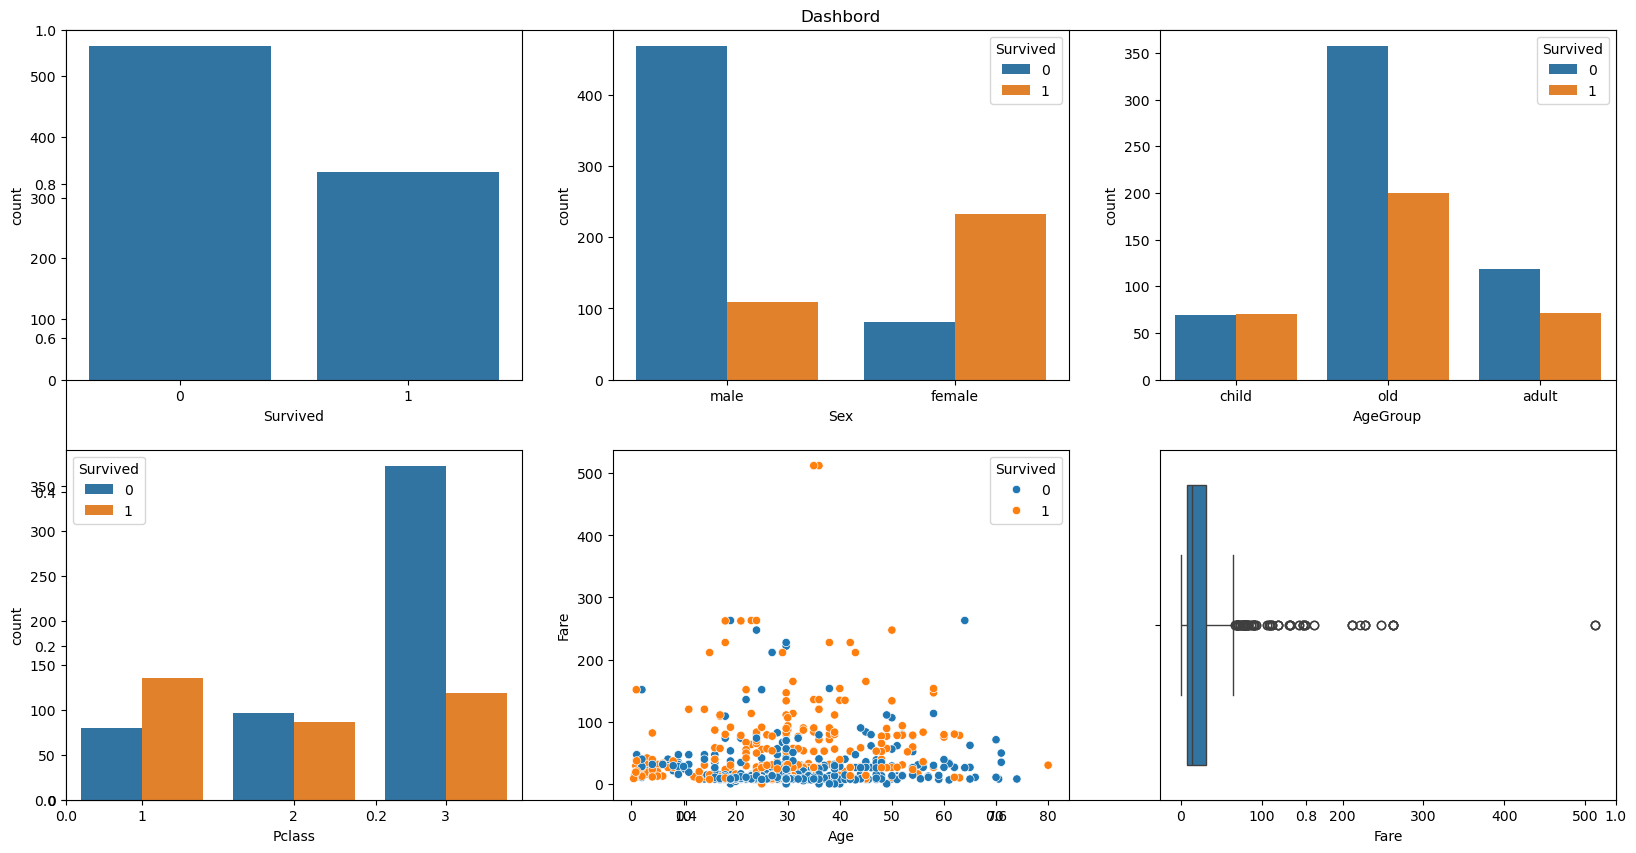

In [105]:

plt.figure(figsize=(20,10))
plt.title("Dashbord")
plt.subplot(2,3,1)
sns.countplot(x="Survived",data=df)
plt.subplot(2,3,3)
sns.countplot(x="AgeGroup",hue="Survived",data=df)
plt.subplot(2,3,2)
sns.countplot(x="Sex",hue="Survived",data=df)
plt.subplot(2,3,4)
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.subplot(2,3,5)
sns.scatterplot(x="Age",y="Fare",hue="Survived",data=df)
plt.subplot(2,3,6)
sns.boxplot(x="Fare",data=df)
plt.show()

Data Storytelling

1) most of the people died in the incident
2) Female were servived more than male
3) old people were rescued 
4) Passenger from 1st class were survived the most
5) people who paid more survived most
6) around 20 people paid more than average price